In [1]:
import directional_tile_codes as dtc

In [2]:
from qldpc.codes import CSSCode
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
word = dtc.DirectionalWord("NNESENN")
code = dtc.DirTileCode(M=4, N=4, word=word)

layout edges:           72
X checks before prune:  32
Z checks before prune:  32
data after prune:       60
X checks after prune:   28
Z checks after prune:   28


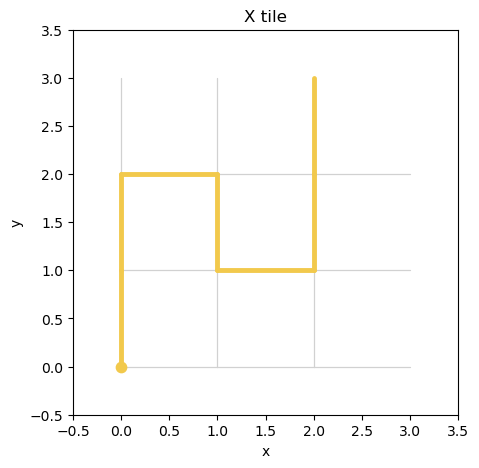

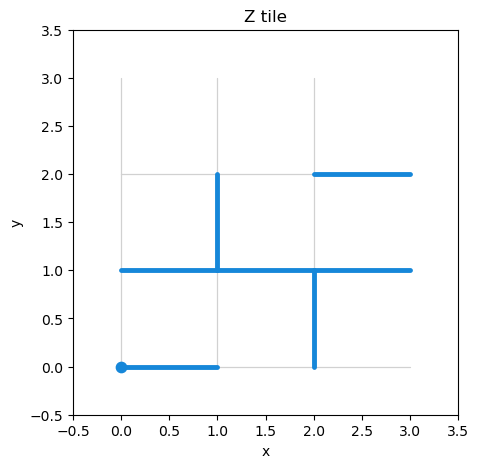

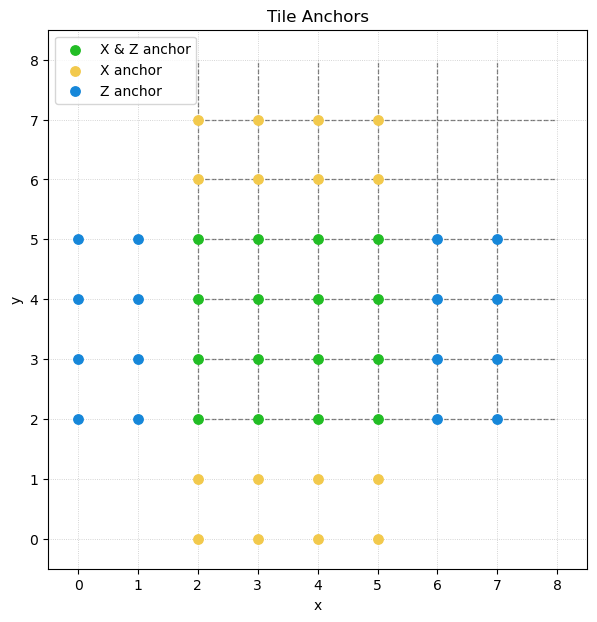

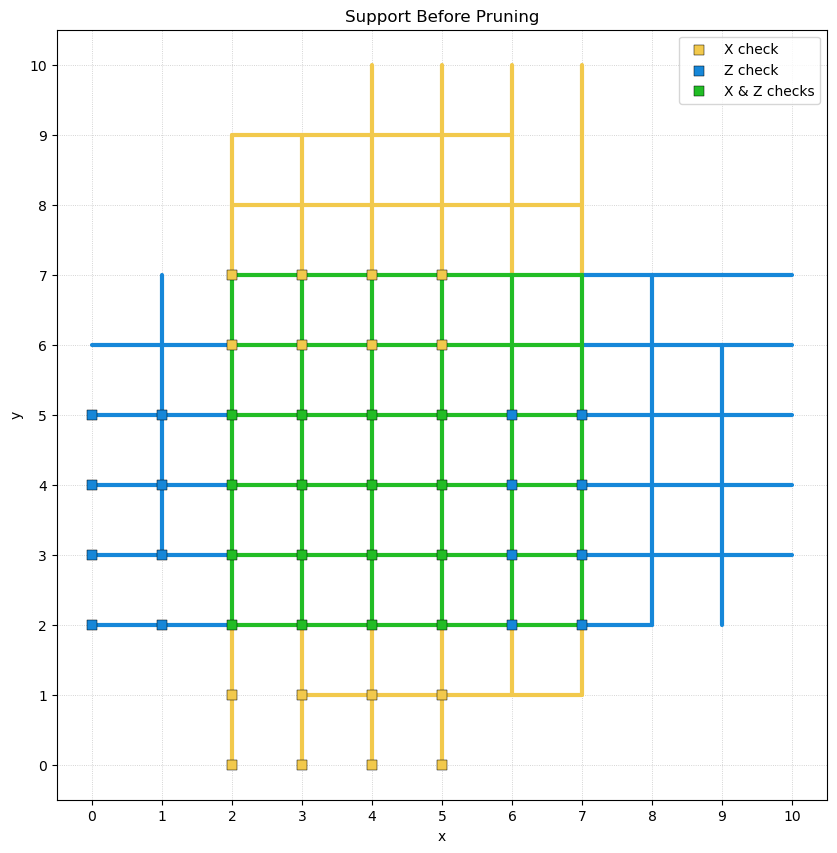

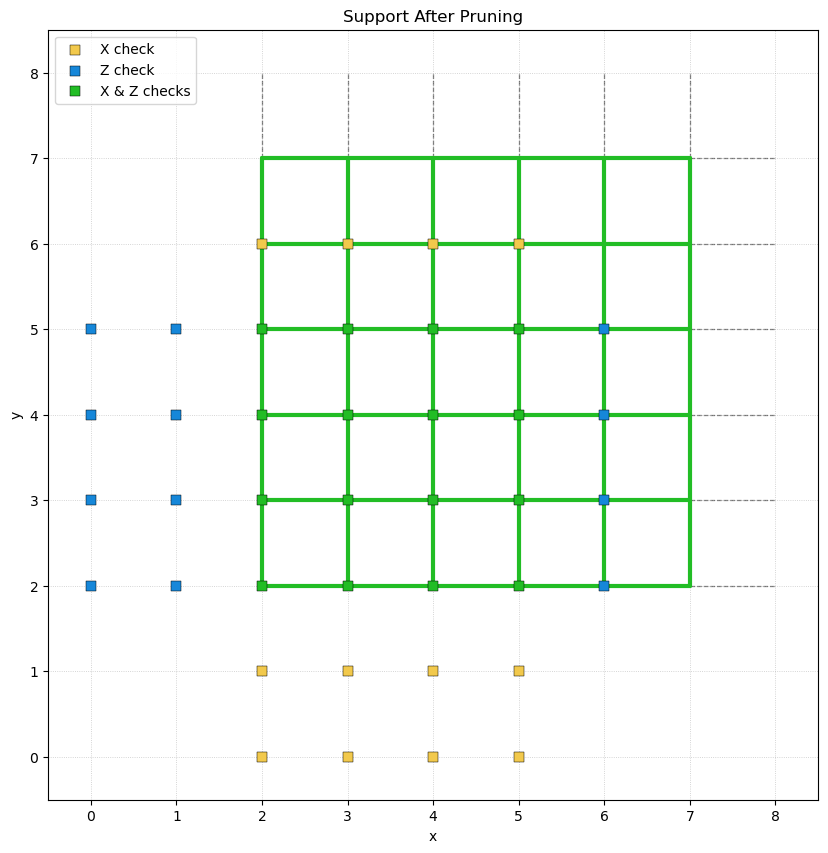

In [4]:
dtc.print_visualization_summary(code)

dtc.plot_x_tile(code)
plt.show()

dtc.plot_z_tile(code)
plt.show()

dtc.plot_anchors(code)
plt.show()

dtc.plot_support_before_prune(code)
plt.show()

dtc.plot_support_after_prune(code)
plt.show()

In [5]:
h_x, h_z = code.parity_check_matrices()
css_code = CSSCode(code_x=h_x, code_z=h_z)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
print("Is self dual: ", css_code.is_self_dual)
print()
print("Classical code of X-type parity checks:\n", css_code.code_x)
print("Classical code of Z-type parity checks:\n", css_code.code_z)
print()
# nx.draw(css_code.graph_x)
# nx.draw(css_code.graph_z)
# print()
print("Number of X-type parity checks: ", css_code.num_checks_x)
print("Number of Z-type parity checks: ", css_code.num_checks_z)
print()
print("Rank: ", css_code.rank)

Is self dual:  False

Classical code of X-type parity checks:
 ClassicalCode on 60 bits, with parity check matrix
[[1 0 0 ... 0 0 0]
 [0 1 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]]
Classical code of Z-type parity checks:
 ClassicalCode on 60 bits, with parity check matrix
[[0 1 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]

Number of X-type parity checks:  28
Number of Z-type parity checks:  28

Rank:  56


### Logical Operators

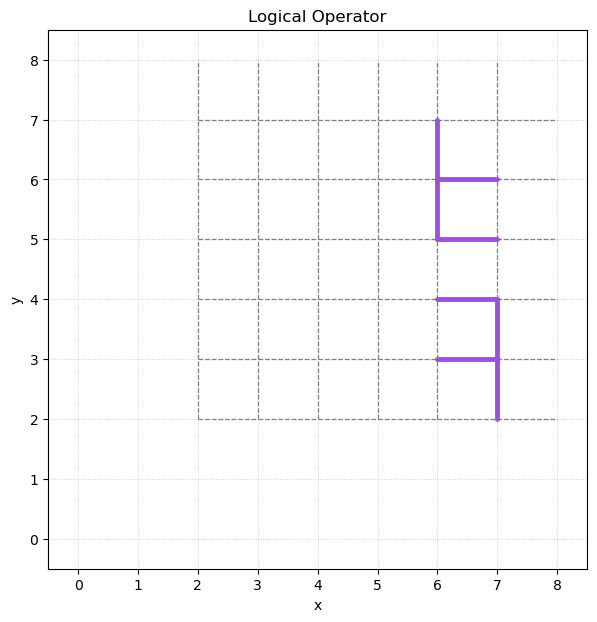

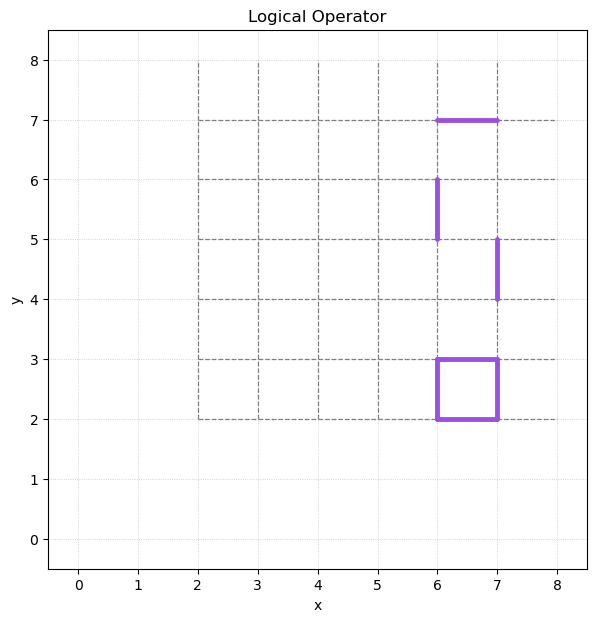

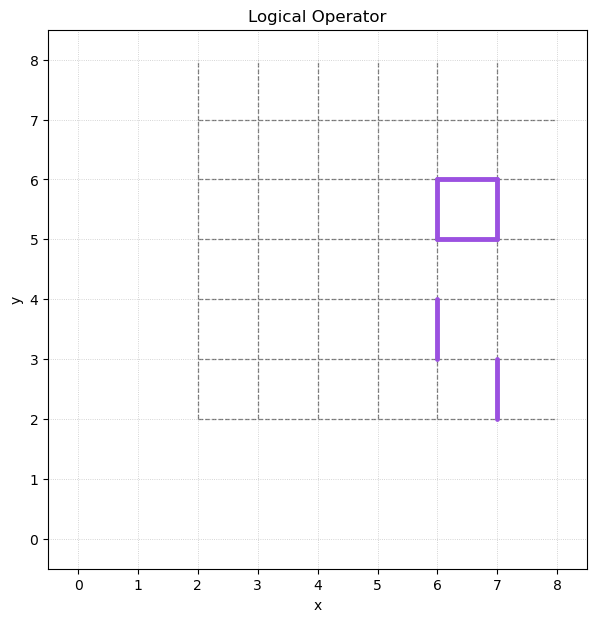

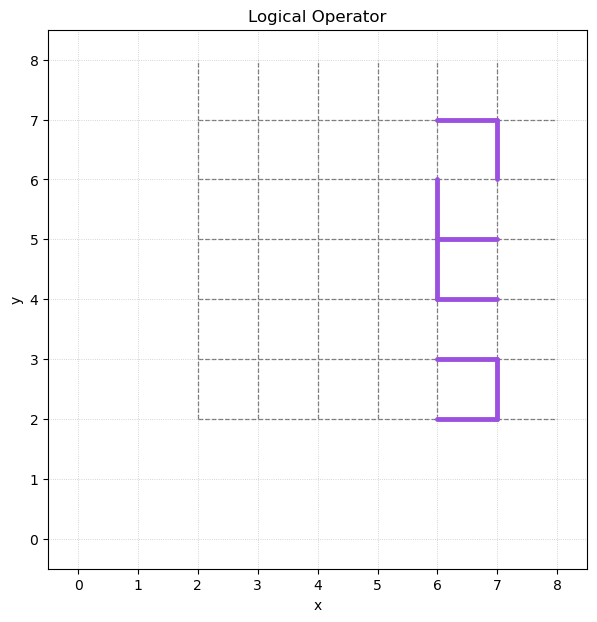

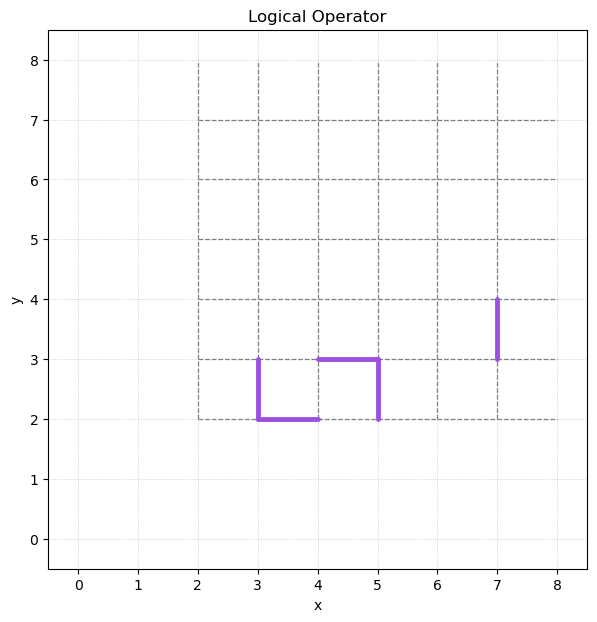

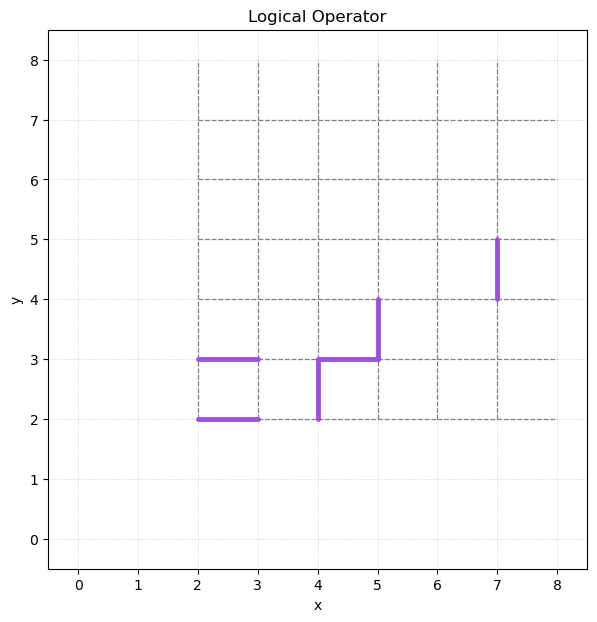

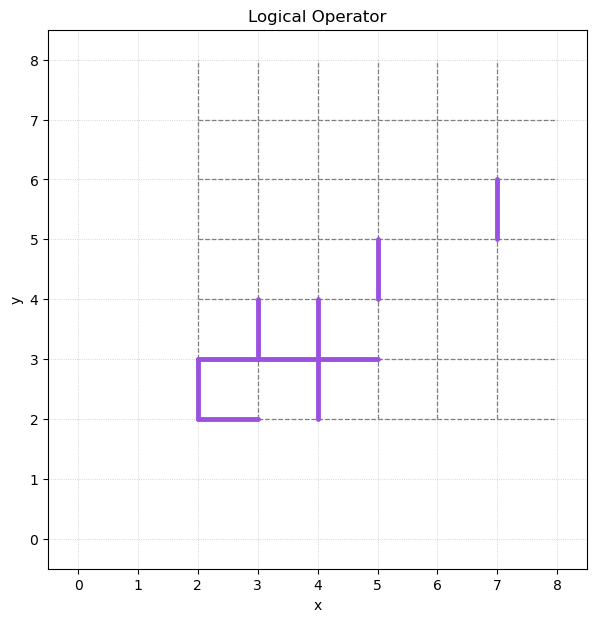

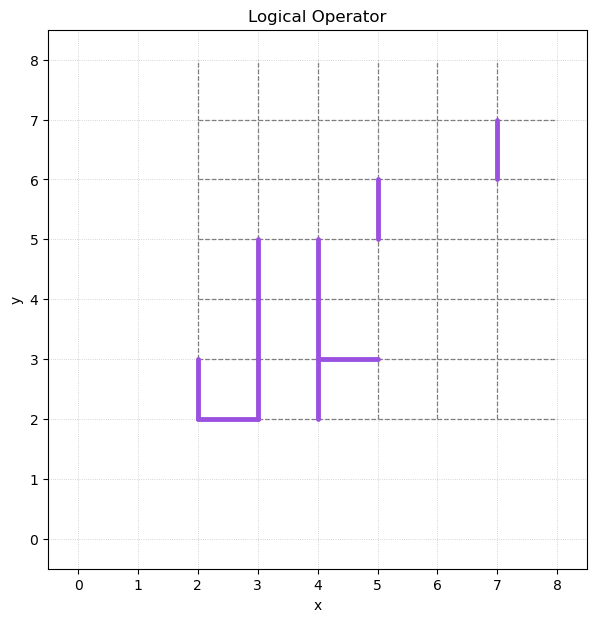

In [7]:
logical_ops = css_code.get_logical_ops()
for logical in logical_ops:
    dtc.plot_logical_operator(code.logical_to_edges(logical), code=code)
    code.add_logical_op(logical)

### Logical Qubits

In [8]:
# rank(h_x) + rank(h_z) = n - k
n = code.n
rank = css_code.rank
k = n - rank

print("Physical qubits: ", n)
print("Logical qubits : ", k)

Physical qubits:  60
Logical qubits :  4


### Distances

In [9]:
d = css_code.get_distance_exact()

print("Exact distance: ", d)

Exact distance:  5


In [10]:
print(f"[[n, k, d]] = [[{n}, {k}, {d}]]")

[[n, k, d]] = [[60, 4, 5]]
